In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from SamplingMethods import Sampler_class
import plotly.express as px
from ax.api.client import Client

# Model Mk16

In [2]:
client = Client()
client = client.load_from_json_file("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/Modelling_Revised/ModelMk16.json")
client.get_next_trials(max_trials=1)
n = 10
iCoords_arr = np.linspace(0,1,n-1)
jCoords_arr = np.linspace(0,1,n-1)
kCoords_arr = np.linspace(0,1,n-1)
ijkCoordsOld_lis = []
ijkCoords_lis = []
for i in iCoords_arr:
    for j in jCoords_arr:
        for k in kCoords_arr:
            ijkCoordsOld_lis.append([i,j,k])
            ijkCoords_lis.append({"s1":i,"s2":j,"b1":k})
y_pred = client.predict(ijkCoords_lis)
y_pred_lis = []
for i in y_pred:
    y_pred_lis.append(i["t1"][0])
ijkCoordsOld_arr = np.array(ijkCoordsOld_lis)
y_pred_arr = np.array(y_pred_lis)
df2 = pd.DataFrame({'s1': ijkCoordsOld_arr[:, 0],'s2': ijkCoordsOld_arr[:, 1],'b1': ijkCoordsOld_arr[:, 2], 'y_pred': y_pred_arr})

fig = px.scatter_3d(df2, x='s1', y='s2', z='b1', color='y_pred')
fig.show()

In [3]:
pseudorandom_100_dodd_27 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel_Revised/DataGenerated/pseudorandom_27.pkl")[0].tolist()
quasirandom_100_dodd_27 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel_Revised/DataGenerated/quasirandom_27.pkl")[0].tolist()
Bayes_100_PI_9_27_3 =  pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel_Revised/DataGenerated/normal_PI_9_27_3.pkl")[0].tolist()
Bayes_100_EI_9_27_3 = pd.read_pickle(filepath_or_buffer="/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/writing/papers/UoC_Paper1/Sandbox/SequentialTestswGPModel_Revised/DataGenerated/normal_EI_9_27_3.pkl")[0].tolist()

Simulations = [pseudorandom_100_dodd_27,quasirandom_100_dodd_27,Bayes_100_PI_9_27_3,Bayes_100_EI_9_27_3]

all = pseudorandom_100_dodd_27+quasirandom_100_dodd_27+Bayes_100_PI_9_27_3+Bayes_100_EI_9_27_3

print(len(pseudorandom_100_dodd_27))
print(len(quasirandom_100_dodd_27))
print(len(Bayes_100_PI_9_27_3))
print(len(Bayes_100_EI_9_27_3))

200
200
200
200


In [4]:
pseudorandom_100_dodd_27_name = []
quasirandom_100_dodd_27_name = []
Bayes_100_PI_9_27_3_name = []
Bayes_100_EI_9_27_3_name = []
for i in range(len(pseudorandom_100_dodd_27)):
    pseudorandom_100_dodd_27_name.append("PR\n27")
    quasirandom_100_dodd_27_name.append("QR\n27")
    Bayes_100_PI_9_27_3_name.append("PI\n9,27,3")
    Bayes_100_EI_9_27_3_name.append("EI\n9,27,3")

all_names = pseudorandom_100_dodd_27_name+quasirandom_100_dodd_27_name+Bayes_100_PI_9_27_3_name+Bayes_100_EI_9_27_3_name

In [5]:
hex = {
    "0":"#F0A638",
    "1":"#F8531C",
    "2":"#538fe3",
    "3":"#4c83d0",
    "4":"#7fdd03",
    "5":"#6cbe01",
    "6":"#5ea402",
    "7":"#000000"
    }

In [6]:
pseudorandom_100_dodd_27_hue = []
quasirandom_100_dodd_27_hue = []
Bayes_100_PI_9_27_3_hue = []
Bayes_100_EI_9_27_3_hue = []
for i in range(len(pseudorandom_100_dodd_27)):
    pseudorandom_100_dodd_27_hue.append("0")
    quasirandom_100_dodd_27_hue.append("1")
    Bayes_100_PI_9_27_3_hue.append("3")
    Bayes_100_EI_9_27_3_hue.append("6")

all_hues = pseudorandom_100_dodd_27_hue+quasirandom_100_dodd_27_hue+Bayes_100_PI_9_27_3_hue+Bayes_100_EI_9_27_3_hue

In [7]:
ndf = pd.DataFrame({"y":all,"type":all_names,"hue":all_hues})
ndf

,y,type,hue
0,14.200809,PR\n27,0
1,15.111747,PR\n27,0
2,14.357289,PR\n27,0
3,14.775199,PR\n27,0
4,14.780459,PR\n27,0
...,...,...,...
795,17.593975,"EI\n9,27,3",6
796,17.743860,"EI\n9,27,3",6
797,17.476221,"EI\n9,27,3",6
798,16.389498,"EI\n9,27,3",6


In [8]:
# plt.gcf().set_size_inches(10, 4)
# sns.set_theme(style="whitegrid")
# ax = sns.swarmplot(x="type", y="y",hue="hue", palette=hex, data=ndf, size=0.75, legend=False)
# df_means = ndf.groupby("type")["y"].agg("mean").reset_index()
# xlim = ax.get_xlim()
# ylim = ax.get_ylim()
# sns.scatterplot(x="type", y="y", marker='X', color='black', s=100, zorder=3, ax=ax, legend=False, data=df_means)
# ax.set_xlim(xlim)
# ax.set_ylim(ylim)
# plt.title(f"Optimising ModelMk4: {len(pseudorandom_100_dodd_27)} Trials & Random 8 Sample Prior")
# plt.xlabel("Optimisation Type")
# plt.ylabel("Best Mass Loss (%)")
# plt.ylim(bottom=12,top=19)
# plt.show()

In [9]:
# Global Maximum
# 18.766577458826873
# [np.float64(0.3469387755102041), np.float64(0.6530612244897959), np.float64(0.7653061224489796)]

In [10]:
# Threshold = 18.5
# SimulationNumberOfPointsExceedingThreshold = []
# PercentageOfPointsExceedingThreshold = []
# for simulation in Simulations:
#     counter = 0
#     for i in simulation:
#         if i > Threshold:
#             counter+=1
#     SimulationNumberOfPointsExceedingThreshold.append(counter)
#     PercentageOfPointsExceedingThreshold.append(round((counter/len(simulation))*100,2))
# print(SimulationNumberOfPointsExceedingThreshold)
# print(PercentageOfPointsExceedingThreshold)

# Visualisation For Paper

In [11]:
nndf = ndf.drop(ndf[ndf['type'] == "PI\n9,27,1"].index)
nndf = nndf.drop(nndf[nndf['type'] == "EI\n9,27,1"].index)
nndf = nndf.drop(nndf[nndf['type'] == "EI\n9,27,2"].index)

nndf = nndf.replace("PR\n27","One-Shot\nPseudorandom")
nndf = nndf.replace("QR\n27","One-Shot\nQuasirandom")
nndf = nndf.replace("PI\n9,27,3","Sequential\nBayesian (PI)")
nndf = nndf.replace("EI\n9,27,3","Sequential\nBayesian (EI)")
nndf

,y,type,hue
0,14.200809,One-Shot\nPseudorandom,0
1,15.111747,One-Shot\nPseudorandom,0
2,14.357289,One-Shot\nPseudorandom,0
3,14.775199,One-Shot\nPseudorandom,0
4,14.780459,One-Shot\nPseudorandom,0
...,...,...,...
795,17.593975,Sequential\nBayesian (EI),6
796,17.743860,Sequential\nBayesian (EI),6
797,17.476221,Sequential\nBayesian (EI),6
798,16.389498,Sequential\nBayesian (EI),6


In [12]:
# plt.gcf().set_size_inches(5, 4)
# sns.set_style("ticks")
# ax = sns.swarmplot(x="type", y="y",hue="hue", palette=hex, data=nndf, size=0.8, legend=False)
# df_means = nndf.groupby("type")["y"].agg("mean").reset_index()
# df_means["hue"]=["0","1","6","3"]
# xlim = ax.get_xlim()
# ylim = ax.get_ylim()
# sns.scatterplot(x="type", y="y", hue="hue", marker='X', palette=hex, color='black', s=100, zorder=3, ax=ax, legend=False, data=df_means, edgecolors="black")
# plt.scatter(x="One-Shot\nPseudorandom",y=20,marker="X",color="black",edgecolors="black",s=100,label="Mean")
# plt.scatter(x="One-Shot\nPseudorandom",y=20,marker=".",color="black",edgecolors="black",s=0.8,label="Simulation")
# ax.set_xlim(xlim)
# ax.set_ylim(ylim)
# # plt.title(f"Optimising ModelMk4: {len(pseudorandom_100_dodd_27)} Trials & Random 8 Sample Prior")
# plt.xlabel("Sampling Method",fontsize=12)
# plt.ylabel(r'Best Percentage Mass Loss, $\Delta$m$^\circ_\%$ (%)',fontsize=12)
# plt.ylim(bottom=12,top=19)
# plt.xticks(fontsize=10)
# plt.legend(loc='upper left',ncols=2,fontsize="10")
# plt.show()

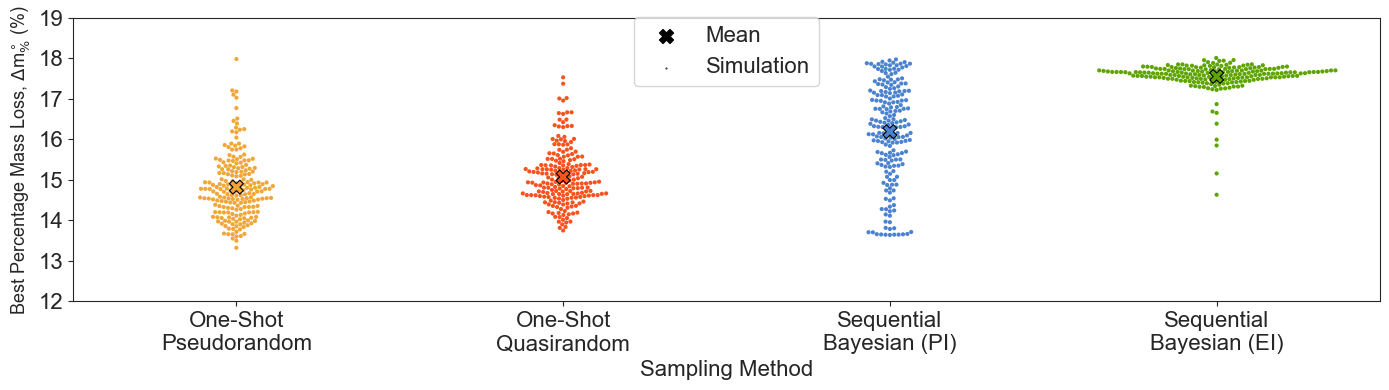

In [13]:
plt.gcf().set_size_inches(14, 4)
sns.set_style("ticks")
# ax = sns.swarmplot(x="type", y="y",hue="hue", palette=hex, data=nndf, size=1.5, legend=False)
ax = sns.swarmplot(x="type", y="y",hue="hue", palette=hex, data=nndf, size=3, legend=False)
df_means = nndf.groupby("type")["y"].agg("mean").reset_index()
df_std = nndf.groupby("type")["y"].agg("std").reset_index()
df_means["hue"]=["0","1","6","3"]
xlim = ax.get_xlim()
ylim = ax.get_ylim()
sns.scatterplot(x="type", y="y", hue="hue", marker='X', palette=hex, color='black', s=100, zorder=3, ax=ax, legend=False, data=df_means, edgecolors="black")
plt.scatter(x="One-Shot\nPseudorandom",y=20,marker="X",color="black",edgecolors="black",s=100,label="Mean")
plt.scatter(x="One-Shot\nPseudorandom",y=20,marker=".",color="black",edgecolors="black",s=0.8,label="Simulation")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
# plt.title(f"Optimising ModelMk4: {len(pseudorandom_100_dodd_27)} Trials & Random 8 Sample Prior")

# plt.hlines(18.5,xmin=-1,xmax=-0.41,linestyle="dashed",alpha=0.3)
# plt.hlines(18.5,xmin=0.9,xmax=4,linestyle="dashed",alpha=0.3)
# plt.text(x=-0.4,y=18.36,s="\"Region of Global Optimality\" Threshold",alpha=0.8,fontsize="14")

plt.xlabel("Sampling Method",fontsize=16)
plt.ylabel(r'Best Percentage Mass Loss, $\Delta$m$^\circ_\%$ (%)',fontsize=13)
plt.ylim(bottom=12,top=19)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(bbox_to_anchor=(0.5, 0.72),ncols=1,fontsize="16")
plt.tight_layout()
plt.savefig(fname='SimulationResultOverview.pdf',dpi=1000,format='pdf')

In [14]:
df_means

,type,y,hue
0,One-Shot\nPseudorandom,14.821878,0
1,One-Shot\nQuasirandom,15.073483,1
2,Sequential\nBayesian (EI),17.555746,6
3,Sequential\nBayesian (PI),16.192301,3


In [15]:
df_std

,type,y
0,One-Shot\nPseudorandom,0.780358
1,One-Shot\nQuasirandom,0.760992
2,Sequential\nBayesian (EI),0.380259
3,Sequential\nBayesian (PI),1.207943
